# Qwen3.5 — RL (GRPO) với Rule-Based Reward từ engagement signals

**Dữ liệu:** `dataset/500 posts diningreview.csv` — bài đăng tiếng Việt + số liệu tương tác.

**Thư viện:** [Transformers](https://github.com/huggingface/transformers), [PEFT](https://github.com/huggingface/peft), [bitsandbytes](https://github.com/TimDettmers/bitsandbytes), [TRL](https://github.com/huggingface/trl) — **GRPOTrainer** chuẩn (policy QLoRA), không dùng Unsloth để tránh patch class-level và cache compile khó gỡ lỗi.

**Model:** đặt `BASE_MODEL` ở ô đầu. Các lựa chọn:
- `Qwen/Qwen3.5-1.7B` · `Qwen/Qwen3.5-4B` · `Qwen/Qwen3.5-9B`
- `unsloth/Qwen3.5-1.7B` / `unsloth/Qwen3.5-4B` (mirror Unsloth)

**VRAM tham khảo (4-bit + LoRA):** 1.7B ~5 GB · 4B ~9 GB · 9B ~18 GB.

**Luồng**
1. Khám phá CSV, phân tích engagement để thiết kế reward.
2. **GRPO (Prefix Completion):** prompt = câu đầu tiên của bài thực, GRPO sinh G completions/prompt → tính reward bằng hàm rule-based → normalize trong group → cập nhật policy. Không cần reward model riêng, không cần value/critic model.

**Tại sao không cần Reward Model?** GRPO dùng **rule-based reward function** — hàm chấm điểm trực tiếp dựa trên các đặc trưng tương quan với engagement cao (độ dài, emoji, CTA, tiếng Việt…). Insight về những đặc trưng này lấy từ phân tích CSV ở phần 1.

**Tại sao Prefix Completion?** Dataset không có prompt — câu đầu mỗi bài đóng vai trò *state*, phần còn lại do model sinh và được reward function chấm điểm. Model học hoàn thiện bài post sao cho "ăn khách".

## 0. Cài đặt (chạy một lần nếu thiếu gói)

In [42]:
# %pip install -U trl transformers accelerate peft bitsandbytes datasets pandas

In [43]:
import os
import re
import unicodedata
from pathlib import Path

import random
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from matplotlib import pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Paths ──────────────────────────────────────────────────────────────────────
REPO_ROOT = Path.cwd().resolve()
CSV_PATH  = REPO_ROOT / "dataset" / "500 posts diningreview.csv"

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_ID = "Qwen/Qwen3.5-2B"   # Đổi: 4B / 9B / unsloth/Qwen3.5-4B …

MAX_SEQ_LENGTH = 1024
LOAD_IN_4BIT   = True
DTYPE          = None

# ── Output dirs ────────────────────────────────────────────────────────────────
MODELS_DIR = REPO_ROOT / "mcs_train_content_model_outputs" / (MODEL_ID.replace("/", "-") + "_rl_grpo")
GRPO_DIR   = str(MODELS_DIR / "grpo_policy")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.is_file(), f"Dataset not found: {CSV_PATH}"
CSV_PATH = str(CSV_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("CSV  :", CSV_PATH)
print("MODEL:", MODEL_ID)
print("OUT  :", MODELS_DIR)

device: cuda
CSV  : /home/dc34rpa/nathan/dataset/500 posts diningreview.csv
MODEL: Qwen/Qwen3.5-2B
OUT  : /home/dc34rpa/nathan/mcs_train_content_model_outputs/Qwen-Qwen3.5-2B_rl_grpo


## 1. Khám phá dữ liệu

CSV có cột: bình luận, nội dung `text`, lượt thích, các reaction, share. Ta gom một **điểm engagement** (proxy cho “bài hay hơn”).

In [44]:
df = pd.read_csv(CSV_PATH, encoding="utf-8")
print("shape:", df.shape)
print(df.columns.tolist())
df.head(3)

shape: (500, 11)
['commentsCount', 'text', 'likesCount', 'reactionAngryCount', 'reactionCareCount', 'reactionHahaCount', 'reactionLikeCount', 'reactionLoveCount', 'reactionSadCount', 'reactionWowCount', 'sharesCount']


,commentsCount,text,likesCount,reactionAngryCount,reactionCareCount,reactionHahaCount,reactionLikeCount,reactionLoveCount,reactionSadCount,reactionWowCount,sharesCount
0,22,CUNG YẾN Ở BẮC KINH. 🫰👍\r\n\r\nKhông biết có a...,38,NaN,NaN,NaN,35,3.0,NaN,NaN,0
1,32,Kính gửi quý thực khách thân yêu🙇🏻‍♀️\r\nEm là...,68,NaN,NaN,NaN,62,6.0,NaN,NaN,3
2,13,"Mến chào cộng đồng Dining Review,\r\n\r\nEm là...",37,NaN,NaN,NaN,30,6.0,NaN,1.0,0


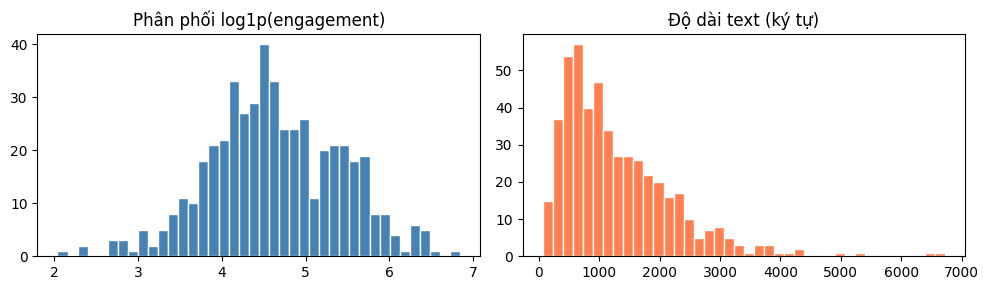

,engage,likesCount,commentsCount
count,492.000000,492.000000,492.000000
mean,4.640319,61.278455,12.376016
std,0.779474,52.278723,16.108810
min,2.041220,3.000000,0.000000
25%,4.126731,27.000000,3.000000
50%,4.577284,43.000000,7.000000
75%,5.234043,83.000000,15.000000
max,6.844176,377.000000,142.000000


In [45]:
num_cols = [
    "commentsCount",
    "likesCount",
    "reactionAngryCount",
    "reactionCareCount",
    "reactionHahaCount",
    "reactionLikeCount",
    "reactionLoveCount",
    "reactionSadCount",
    "reactionWowCount",
    "sharesCount",
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0)

df["text"] = df["text"].astype(str)
df = df[df["text"].str.len() > 50].copy()

df["engage"] = (
    df["likesCount"]
    + 0.5 * df["commentsCount"]
    + 1.5 * df["sharesCount"]
    + df["reactionLikeCount"]
    + 1.2 * df["reactionLoveCount"]
    + 0.8 * df["reactionHahaCount"]
    + 0.8 * df["reactionCareCount"]
    + 0.8 * df["reactionWowCount"]
    - 0.5 * df["reactionAngryCount"]
    - 0.3 * df["reactionSadCount"]
)
df["engage"] = np.log1p(np.maximum(df["engage"], 0))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(df["engage"], bins=40, color="steelblue", edgecolor="white")
ax[0].set_title("Phân phối log1p(engagement)")
ax[1].hist(df["text"].str.len(), bins=40, color="coral", edgecolor="white")
ax[1].set_title("Độ dài text (ký tự)")
plt.tight_layout()
plt.show()

df[["engage", "likesCount", "commentsCount"]].describe()

## 2. GRPO — Policy (QLoRA) + Rule-Based Reward, Prefix Completion

**Prompt = câu đầu tiên** của mỗi bài thực trong CSV. GRPO sinh `num_generations` completions cho mỗi prompt, dùng **hàm reward rule-based** chấm điểm, rồi normalize trong group để tính advantage — không cần reward model hay value/critic model riêng.

**Reward function** chấm điểm trực tiếp dựa trên các đặc trưng tương quan với engagement cao trong dataset:
- **Độ dài** phù hợp cho Facebook post (150–1000 ký tự)
- **Emoji** (tương quan dương với likes/reactions)
- **CTA / câu hỏi** tương tác (comment, chia sẻ, đặt bàn…)
- **Tiếng Việt** có dấu (đảm bảo model không sinh tiếng Anh)
- **Kết thúc hoàn chỉnh** (có dấu câu cuối)

Dataset chỉ cần cột `prompt` (string). GRPOTrainer tự tokenize và xử lý padding.

In [46]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig, TaskType, get_peft_model, prepare_model_for_kbit_training

bnb_config = BitsAndBytesConfig(
    load_in_4bit=LOAD_IN_4BIT,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
    bnb_4bit_use_double_quant=True,
)

policy = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto" if torch.cuda.is_available() else None,
    trust_remote_code=True,
)
tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

policy = prepare_model_for_kbit_training(policy, use_gradient_checkpointing=True)

peft_policy_cfg = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
policy = get_peft_model(policy, peft_policy_cfg)
policy.print_trainable_parameters()

# Prefix Completion: lấy câu đầu tiên của mỗi bài thực làm prompt
def extract_first_sentence(text, min_len=15, max_len=200):
    match = re.search(r'(?<=[^\d])[.!?…]', text[min_len:])
    if match:
        return text[:min_len + match.start() + 1].strip()
    return text[:max_len].strip()

def build_grpo_dataset(frame, n=256, seed=SEED):
    sample = frame.sample(min(n, len(frame)), replace=n > len(frame), random_state=seed)
    rows = [
        {"prompt": extract_first_sentence(row["text"])}
        for _, row in sample.iterrows()
        if len(row["text"]) > 50
    ]
    return Dataset.from_list(rows[:n])

grpo_train = build_grpo_dataset(df, n=256)
grpo_eval  = build_grpo_dataset(df, n=32, seed=SEED + 1)

print("Train:", grpo_train)
print("Eval :", grpo_eval)
print("\nVí dụ prompt:", grpo_train[0]["prompt"])

Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

/home/dc34rpa/nathan/myenv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


trainable params: 10,911,744 || all params: 1,892,736,832 || trainable%: 0.5765
Train: Dataset({
    features: ['prompt'],
    num_rows: 256
})
Eval : Dataset({
    features: ['prompt'],
    num_rows: 32
})

Ví dụ prompt: Vien Dining - Hanoi - menu mới
Vien Dining là nhà hàng yêu thích của mình ở HN, menu nào mới ra cũng đi ăn cả set và ALC, quen chủ nên đc giảm giá thoai chứ đi ăn vẫn trả tiền đàng quàng nên ko seeding gì nha.


In [47]:
# GRPO không cần value/critic model hay reward model riêng.
# Advantage = normalize reward trong group G completions của mỗi prompt:
#   A_i = (r_i - mean(r)) / (std(r) + eps)
# Policy cập nhật theo hướng tăng xác suất completion có A_i > 0.

In [48]:
# Patch TRL import breakages caused by inconsistent package versions in this env.
# - llm_blender: optional TRL dep whose availability check lies (reports available but can't import)
# - ProfilingContext: added in newer grpo_trainer.py but missing from installed profiling.py
import sys
from unittest.mock import MagicMock

if "llm_blender" not in sys.modules:
    sys.modules["llm_blender"] = MagicMock()

import trl.extras.profiling as _trl_prof
if not hasattr(_trl_prof, "ProfilingContext"):
    _trl_prof.ProfilingContext = MagicMock()

print("TRL patches applied.")

TRL patches applied.


In [49]:
from trl import GRPOConfig, GRPOTrainer

# Rule-based reward function — không cần reward model
# Các đặc trưng dựa trên insight từ phân tích engagement ở phần 1
def reward_fn(completions, **kwargs):
    scores = []
    for text in completions:
        r = 0.0

        n = len(text.strip())

        # Độ dài phù hợp cho Facebook post
        if n < 30:
            r -= 2.0
        elif 150 <= n <= 1000:
            r += 1.0
        elif n > 2000:
            r -= 0.5

        # Emoji (tương quan dương với likes/reactions trong dataset)
        emoji_count = sum(
            1 for c in text
            if unicodedata.category(c) in ("So", "Sm") or 0x1F300 <= ord(c) <= 0x1FAFF
        )
        r += min(emoji_count * 0.15, 0.6)

        # CTA hoặc câu hỏi tương tác
        if re.search(r"[?？]", text):
            r += 0.3
        cta_words = ["bình luận", "comment", "chia sẻ", "tag", "inbox",
                     "đặt bàn", "liên hệ", "để lại", "cho mình biết", "dm"]
        if any(w in text.lower() for w in cta_words):
            r += 0.4

        # Kết thúc hoàn chỉnh
        if text.strip() and text.strip()[-1] in ".!?…":
            r += 0.2

        # Tiếng Việt có dấu (tránh sinh tiếng Anh)
        viet_chars = len(re.findall(
            r"[àáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỵỷỹ]",
            text, re.IGNORECASE,
        ))
        if viet_chars > 5:
            r += 0.3

        scores.append(r)
    return scores

grpo_args = GRPOConfig(
    output_dir=GRPO_DIR,
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_generations=4,           # G: số completions sinh ra mỗi prompt
    max_completion_length=256,
    temperature=0.7,
    learning_rate=3e-6,
    beta=0.04,                   # KL penalty so với reference policy
    loss_type="grpo",            # pin to classic GRPO loss; newer GRPOConfig defaults to "dapo" which this trainer version doesn't support
    gradient_checkpointing=True,
    bf16=torch.cuda.is_available(),
    logging_steps=1,
    save_steps=50,
    report_to="none",
)

# GRPOTrainer (newer versions) expects model.warnings_issued dict from transformers>=4.46.
# PEFT wraps the base model so the attribute is missing; inject it directly.
if not hasattr(policy, "warnings_issued"):
    policy.__dict__["warnings_issued"] = {}

grpo = GRPOTrainer(
    model=policy,
    args=grpo_args,
    processing_class=tok,
    reward_funcs=reward_fn,
    train_dataset=grpo_train,
    eval_dataset=grpo_eval,
)
grpo.train()
grpo.save_model(GRPO_DIR)
tok.save_pretrained(GRPO_DIR)
print("Đã lưu policy GRPO tại:", GRPO_DIR)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 248046, 'pad_token_id': 248044}.


Step,Training Loss
1,-0.000000
2,0.000023
3,0.000010
4,0.000033
5,0.000007
6,0.000012
7,0.000005
8,0.000023
9,0.000029
10,0.000014


Đã lưu policy GRPO tại: /home/dc34rpa/nathan/mcs_train_content_model_outputs/Qwen-Qwen3.5-2B_rl_grpo/grpo_policy


## 3. Thử sinh văn bản sau GRPO

Lấy câu đầu ngẫu nhiên từ `df` làm prompt — đúng với cách model được huấn luyện (prefix completion).

In [50]:
policy.eval()

test_prompt = extract_first_sentence(
    df.sample(1, random_state=SEED)["text"].values[0]
)
print("Prompt (câu đầu thực):", test_prompt)
print("-" * 60)

_dev = next(policy.parameters()).device
inputs = tok(test_prompt, return_tensors="pt")
inputs = {k: v.to(_dev) for k, v in inputs.items()}
out = policy.generate(
    input_ids=inputs["input_ids"],
    attention_mask=inputs["attention_mask"],
    max_new_tokens=256,
    temperature=0.7,
    do_sample=True,
    pad_token_id=tok.pad_token_id,
)
generated = tok.decode(out[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True)
print("Completion:\n", generated)

Prompt (câu đầu thực): Vien Dining - Hanoi - menu mới
Vien Dining là nhà hàng yêu thích của mình ở HN, menu nào mới ra cũng đi ăn cả set và ALC, quen chủ nên đc giảm giá thoai chứ đi ăn vẫn trả tiền đàng quàng nên ko seeding gì nha.
------------------------------------------------------------


/home/dc34rpa/nathan/myenv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Completion:
 

<think>

</think>

Chào bạn, mình hiểu rõ nhé! Vient Dining (và các nhà hàng VN ở Hanoi) có một đặc điểm rất nổi tiếng: **tính cộng đồng và sự thân thiện**. Dù có menu mới hay Set meal/Meal of the Day (MOA), bạn vẫn sẽ được chủ nhà hàng hỏi thăm, chào hỏi và đôi khi còn được hỗ trợ giảm giá (thường gọi là "giảm giá chủ" hay "khách mời" nếu bạn là người quen).

Tuy nhiên, để bạn có trải nghiệm tốt nhất, mình xin chia sẻ thêm một số **lời khuyên thực tế** khi đi ăn tại Vient Dining hoặc các nhà hàng VN ở HN, đặc biệt là khi bạn là khách hàng thân thiết (quán quen):

### 1. Về cơ chế giảm giá (Quan trọng)
*   **Quy trình:** Bạn chỉ cần gọi theo số cho chủ nhà hàng là có. Chủ nhà hàng thường hỏi: *"Kính gửi [Tên bạn], hôm nay có người quen chưa? Có khách mời không?"*
*   **Điều kiện:** Cần có nhân viên phục vụ (thường là nhân viên trong khu vực hoặc người quản lý) để gọi và xác nhận.


## 4. Merge LoRA + Xuất GGUF (LM Studio & Ollama)

Chạy sau khi train xong và có `GRPO_DIR`.

- **Bước 1:** Load base model + LoRA adapter, merge thành 1 model fp16, lưu vào `merged_16bit`.
- **Bước 2:** Dùng Unsloth (chỉ để export, không train) xuất GGUF vào `gguf`.

Đổi `GGUF_QUANT` sang `q4_k_m` / `q5_k_m` / `q8_0` nếu cần file nhỏ hơn. Mặc định `f16` — chất lượng cao nhất, không mất mát do quantization.

Hướng dẫn import vào LM Studio: xem [README.md](../README.md#lm-studio-importing-fine-tuned-models).

In [51]:
import gc
from pathlib import Path
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

assert Path(GRPO_DIR).exists(), f"Chưa có GRPO adapter, hãy chạy train trước: {GRPO_DIR}"

MERGED_DIR = MODELS_DIR / "merged_16bit"
GGUF_DIR   = MODELS_DIR / "gguf"
MERGED_DIR.mkdir(parents=True, exist_ok=True)
GGUF_DIR.mkdir(parents=True, exist_ok=True)

SAVE_MERGED_16BIT = True
GGUF_QUANT = "f16"

# Bước 1: merge LoRA adapter vào base model (fp16)
print("Loading base + merging LoRA adapter...")
_base = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
_merged = PeftModel.from_pretrained(_base, GRPO_DIR)
_merged = _merged.merge_and_unload()

if SAVE_MERGED_16BIT:
    print("Saving merged 16-bit →", MERGED_DIR)
    _merged.save_pretrained(str(MERGED_DIR))
    AutoTokenizer.from_pretrained(GRPO_DIR, trust_remote_code=True).save_pretrained(str(MERGED_DIR))
    print("Đã lưu merged 16-bit:", MERGED_DIR)

del _base, _merged
gc.collect()
torch.cuda.empty_cache()

# Bước 2: xuất GGUF qua Unsloth (chỉ dùng để export, không train)
print("\nExporting GGUF →", GGUF_DIR, "| quant =", GGUF_QUANT)
from unsloth import FastLanguageModel
_model_u, _tok_u = FastLanguageModel.from_pretrained(
    model_name=str(MERGED_DIR),
    max_seq_length=1024,
    dtype=None,
    load_in_4bit=False,
)
_model_u.save_pretrained_gguf(str(GGUF_DIR), _tok_u, quantization_method=GGUF_QUANT)

del _model_u, _tok_u
gc.collect()
torch.cuda.empty_cache()
print("Xong. GGUF:", GGUF_DIR)

Loading base + merging LoRA adapter...


NameError: name 'BASE_MODEL' is not defined